# Histogramas en Python

## Histogramas en Python puro

In [1]:
x = (0, 1, 1, 1, 2, 2, 3, 7, 7, 7, 25)

In [2]:
def count_elements(seq) -> dict:
    """
    Función que cuenta las frecuencias
    de aparición de cada elemento de la secuencia,
    creando un diccionario como si fuese una 
    tabla de frecuencias
    """
    hist = {}
    for i in seq:
        hist[i] = hist.get(i, 0) + 1
    return hist

In [3]:
fAbs = count_elements(x)
fAbs

{0: 1, 1: 3, 2: 2, 3: 1, 7: 3, 25: 1}

In [4]:
from collections import Counter

In [5]:
fAbs2 = Counter(x)
fAbs2

Counter({0: 1, 1: 3, 2: 2, 3: 1, 7: 3, 25: 1})

In [6]:
fAbs.items() == fAbs2.items()

True

In [7]:
def ascii_histogram(seq) -> None:
    """
    Un histograma de frecuencias absolutas
    colocado en horizontal y con caracteres ASCII
    """
    fAbs = count_elements(seq)
    for k in sorted(fAbs):
        print("{0:5d} {1}".format(k, "+"*fAbs[k]))

In [8]:
ascii_histogram(x)

    0 +
    1 +++
    2 ++
    3 +
    7 +++
   25 +


In [9]:
import random
random.seed(2019)

In [10]:
vals = [1, 2, 3, 5, 7, 8, 9, 10]
freqs = (random.randint(5, 20) for _ in vals)

In [11]:
data = []
for k, v in zip(vals, freqs):
    data.extend([k]*v)

In [12]:
ascii_histogram(data)

    1 +++++++++
    2 ++++++++++++
    3 ++++++++++++++++++++
    5 ++++++++++
    7 ++++++++++++
    8 ++++++++++++
    9 +++++++++++++++
   10 ++++++++++++++


## Histogramas con NumPy

In [13]:
import numpy as np

In [14]:
np.random.seed(2019)

In [15]:
np.set_printoptions(precision=3)

In [16]:
x = np.random.laplace(loc=10, scale=3, size=1000)

In [17]:
x[:10]

array([14.935,  9.278, 10.855, 10.968, 14.294,  8.459, 11.555, 14.926,
       14.316,  9.373])

In [18]:
hist, bin_edges = np.histogram(x)

In [19]:
hist

array([  1,   0,   0,   8,  48, 194, 542, 167,  31,   9], dtype=int64)

In [20]:
bin_edges

array([-19.167, -14.642, -10.118,  -5.593,  -1.069,   3.455,   7.98 ,
        12.504,  17.029,  21.553,  26.077])

In [21]:
hist.size, bin_edges.size

(10, 11)

In [22]:
min_edge = x.min()
max_edge = x.max()

In [23]:
n_bins = 10
bin_edges = np.linspace(start=min_edge, stop=max_edge, num=n_bins+1, endpoint=True)

In [24]:
bin_edges

array([-19.167, -14.642, -10.118,  -5.593,  -1.069,   3.455,   7.98 ,
        12.504,  17.029,  21.553,  26.077])

In [25]:
x = (0, 1, 1, 1, 2, 2, 3, 7, 7, 7, 25)

In [26]:
bcount = np.bincount(x)
bcount

array([1, 3, 2, 1, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1], dtype=int64)

In [27]:
hist, _ = np.histogram(x, range=(0, max(x)), bins=max(x)+1)

In [28]:
hist

array([1, 3, 2, 1, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1], dtype=int64)

In [29]:
np.array_equal(bcount, hist)

True

In [30]:
dict(zip(np.unique(x), bcount[bcount.nonzero()]))

{0: 1, 1: 3, 2: 2, 3: 1, 7: 3, 25: 1}

## Visualización de histogramas con Matplotlib y Pandas

In [31]:
import matplotlib.pyplot as plt

In [32]:
np.random.seed(2019)
x = np.random.laplace(loc=10, scale=3, size=1000)

(0.0, 140.0)

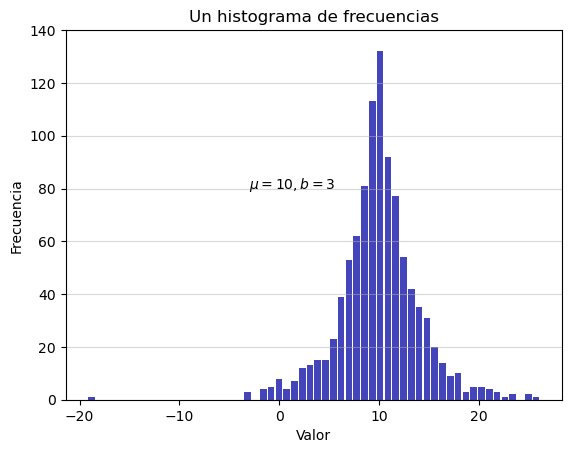

In [33]:
n, bins, patches = plt.hist(x=x, bins="auto", color="#0505A5", alpha=0.75, rwidth=0.85)
plt.grid(axis="y", alpha=0.5)
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.title("Un histograma de frecuencias")
plt.text(-3, 80, r'$\mu = 10, b = 3$')
maxfreq = n.max()
plt.ylim(ymax=np.ceil(maxfreq/10)*10 if maxfreq%10 else maxfreq+10)

In [34]:
n

array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,   0.,
         4.,   5.,   8.,   4.,   7.,  12.,  13.,  15.,  15.,  23.,  39.,
        53.,  62.,  81., 113., 132.,  92.,  77.,  54.,  42.,  35.,  31.,
        20.,  14.,   9.,  10.,   3.,   5.,   5.,   4.,   3.,   1.,   2.,
         0.,   2.,   1.])

In [35]:
patches

<a list of 58 Patch objects>

In [36]:
import pandas as pd

In [37]:
size, scale = 1000, 10
data = pd.Series(np.random.gamma(scale, size=size))

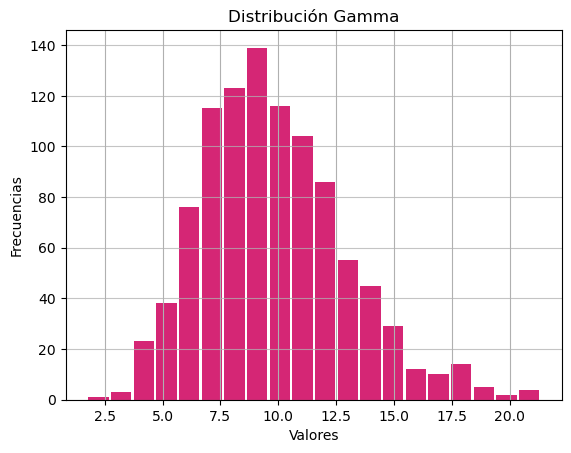

In [38]:
data.plot.hist(grid=True, bins=20, rwidth=0.9, color="#D52675")
plt.title("Distribución Gamma")
plt.xlabel("Valores")
plt.ylabel("Frecuencias")
plt.grid(axis="y", alpha=0.75)

## Funciones de densidad y de probabilidad

In [39]:
mu = 10, 20
sigma = 5, 2
dist = pd.DataFrame(np.random.normal(loc=mu, scale=sigma, size=(1000, 2)), columns=["x1", "x2"])

In [40]:
dist.agg(["min", "max", "mean", "std"]).round(decimals=2)

,x1,x2
min,-5.83,13.84
max,26.05,27.17
mean,9.96,19.89
std,4.97,1.96


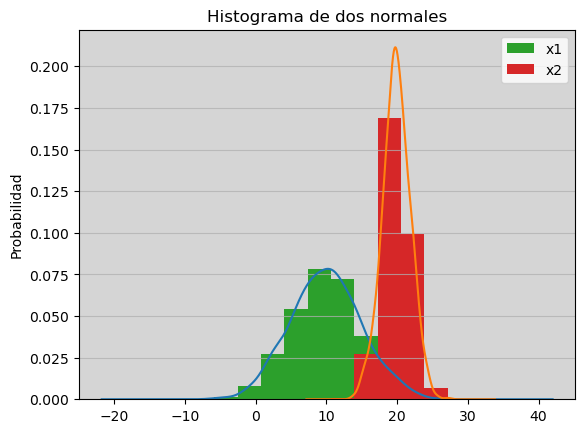

In [41]:
fig, ax = plt.subplots()
dist.plot.kde(ax=ax, legend=False, title="Histograma de dos normales")
dist.plot.hist(density=True, ax=ax)
ax.set_ylabel("Probabilidad")
ax.grid(axis="y", alpha=0.75)
ax.set_facecolor("#D5D5D5")

In [42]:
from scipy import stats

In [43]:
dist = stats.norm() # distribución normal teórica N(0,1) ~ exp(-x**2/2)/sqrt(2*pi)

In [44]:
sample = dist.rvs(size=1000)

In [45]:
stats.norm.ppf(0.01)

-2.3263478740408408

In [46]:
stats.norm.ppf(0.99)

2.3263478740408408

In [47]:
x = np.linspace(start=stats.norm.ppf(0.01), stop=stats.norm.ppf(0.99), num=250)

In [48]:
gkde = stats.gaussian_kde(dataset=sample)

Text(-2, 0.35, '$f(x) = \\frac{e^{-x^2/2}}{\\sqrt{2\\pi}}$')

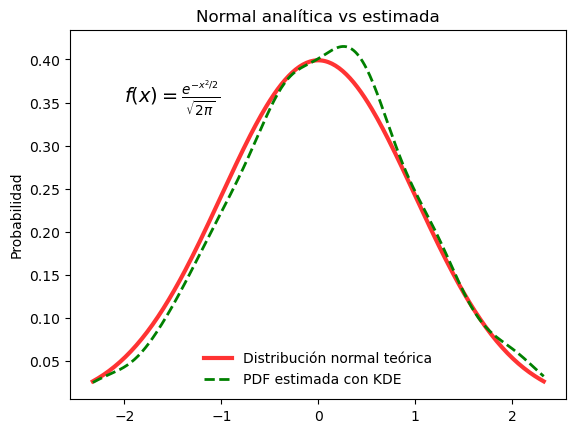

In [49]:
fig, ax = plt.subplots()
ax.plot(x, dist.pdf(x), linestyle="solid", c="red", lw=3, alpha=0.8, label="Distribución normal teórica")
ax.plot(x, gkde.evaluate(x), linestyle="dashed", c="green", lw=2, label="PDF estimada con KDE")
ax.legend(loc="best", frameon=False)
ax.set_title("Normal analítica vs estimada")
ax.set_ylabel("Probabilidad")
ax.text(-2, 0.35, r'$f(x) = \frac{e^{-x^2/2}}{\sqrt{2\pi}}$', fontsize=14)

## Histogramas con Seaborn

In [50]:
import seaborn as sns

C:\Users\mudar\anaconda3\envs\r-basic\lib\site-packages\ipykernel_launcher.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """Entry point for launching an IPython kernel.


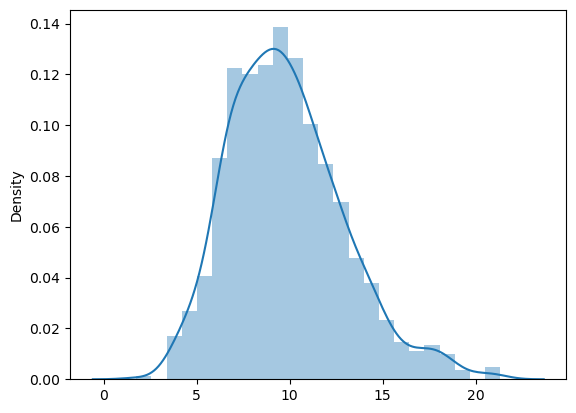

In [51]:
sns.distplot(data)

C:\Users\mudar\anaconda3\envs\r-basic\lib\site-packages\ipykernel_launcher.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  after removing the cwd from sys.path.


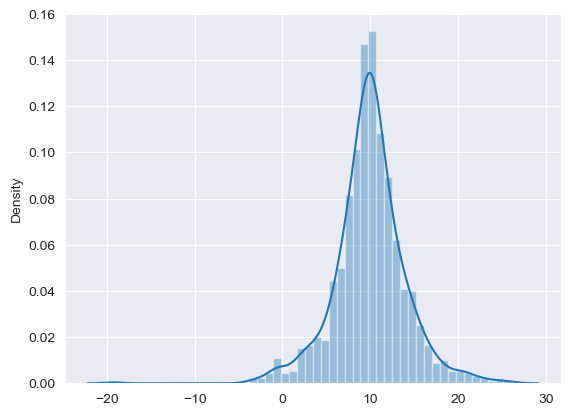

In [52]:
np.random.seed(2019)
x = np.random.laplace(loc=10, scale=3, size=1000)
sns.set_style("darkgrid")
sns.distplot(x)

C:\Users\mudar\anaconda3\envs\r-basic\lib\site-packages\ipykernel_launcher.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """Entry point for launching an IPython kernel.


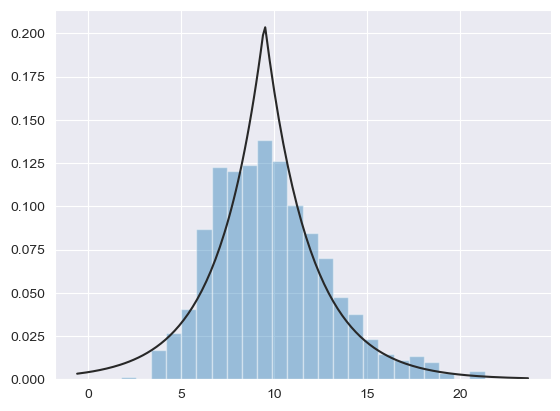

In [53]:
sns.distplot(data, fit=stats.laplace, kde=False)

### Otras formas

In [54]:
data2 = np.random.choice(np.arange(10), size=10000, p=np.linspace(1, 11, 10)/60)

In [55]:
s = pd.Series(data2)

In [56]:
s.value_counts()

9    1840
8    1622
7    1478
6    1276
5    1050
4     909
3     781
2     537
1     361
0     146
dtype: int64

In [57]:
s.value_counts(normalize=True)

9    0.1840
8    0.1622
7    0.1478
6    0.1276
5    0.1050
4    0.0909
3    0.0781
2    0.0537
1    0.0361
0    0.0146
dtype: float64

In [58]:
ages = pd.Series([1, 1, 3, 5, 6, 8, 9, 10, 12, 15, 18, 18, 18, 20, 25, 30, 40, 51, 52])
bins = (0, 10, 15, 18, 21, np.inf)
labels = ("Infancia", "Preadolescencia", "Adolescencia", "Universitario", "Adulto")
groups = pd.cut(ages, bins=bins, labels=labels)

In [59]:
groups

0            Infancia
1            Infancia
2            Infancia
3            Infancia
4            Infancia
5            Infancia
6            Infancia
7            Infancia
8     Preadolescencia
9     Preadolescencia
10       Adolescencia
11       Adolescencia
12       Adolescencia
13      Universitario
14             Adulto
15             Adulto
16             Adulto
17             Adulto
18             Adulto
dtype: category
Categories (5, object): ['Infancia' < 'Preadolescencia' < 'Adolescencia' < 'Universitario' < 'Adulto']

In [60]:
groups.value_counts()

Infancia           8
Adulto             5
Adolescencia       3
Preadolescencia    2
Universitario      1
dtype: int64

In [61]:
pd.concat((ages, groups), axis=1)

,0,1
0,1,Infancia
1,1,Infancia
2,3,Infancia
3,5,Infancia
4,6,Infancia
5,8,Infancia
6,9,Infancia
7,10,Infancia
8,12,Preadolescencia
9,15,Preadolescencia


In [62]:
pd.concat((ages, groups), axis=1).rename(columns={0: "age", 1: "groups"})

,age,groups
0,1,Infancia
1,1,Infancia
2,3,Infancia
3,5,Infancia
4,6,Infancia
5,8,Infancia
6,9,Infancia
7,10,Infancia
8,12,Preadolescencia
9,15,Preadolescencia
